In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

<h2>Load Cleaned Dataset</h2>

In [3]:
DATA_PATH = (
    PROCESSED_DATA_DIR /
    "online_retail_cleaned.csv"
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["InvoiceDate"]
)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

Rows: 1,010,535
Columns: 24


<h2>Inspect Columns</h2>

In [4]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TransactionType', 'IsZeroPrice', 'DescriptionClean', 'Year', 'Month', 'MonthName', 'Quarter', 'Day', 'DayOfWeek', 'DayName', 'Hour', 'IsWeekend', 'YearMonth', 'TotalPrice', 'PriceOutlier_IQR', 'PriceOutlier_ZScore']


<h2>Understand the Basket</h2>
<p>A basket is one invoice/order.</p>
For example:

Invoice 536365


Product A
Product B
Product C

means the customer purchased all three products together.

<h2>Remove Invalid Transactions</h2>

In [5]:
basket_df = df.copy()

basket_df = basket_df[
    basket_df["Quantity"] > 0
].copy()

basket_df = basket_df[
    basket_df["UnitPrice"] > 0
].copy()

print(
    f"Valid basket rows: "
    f"{len(basket_df):,}"
)

Valid basket rows: 1,007,914


<h2>Remove Missing Product Descriptions</h2>

In [6]:
basket_df = basket_df[
    basket_df["DescriptionClean"].notna()
].copy()

basket_df = basket_df[
    basket_df["DescriptionClean"].str.strip() != ""
].copy()

print(
    f"Rows after description filtering: "
    f"{len(basket_df):,}"
)

Rows after description filtering: 1,007,914


<h2>Count Orders</h2>

In [7]:
total_orders = (
    basket_df["Invoice"]
    .nunique()
)

print(
    f"Unique valid orders: "
    f"{total_orders:,}"
)

Unique valid orders: 40,081


<h2>Count Products per Order</h2>

In [8]:
items_per_order = (
    basket_df
    .groupby("Invoice")["StockCode"]
    .nunique()
)

items_per_order.describe()

count   40,081.0000
mean        24.8634
std         42.1772
min          1.0000
25%          6.0000
50%         15.0000
75%         28.0000
max      1,110.0000
Name: StockCode, dtype: float64

<h2>Distribution of Basket Size</h2>

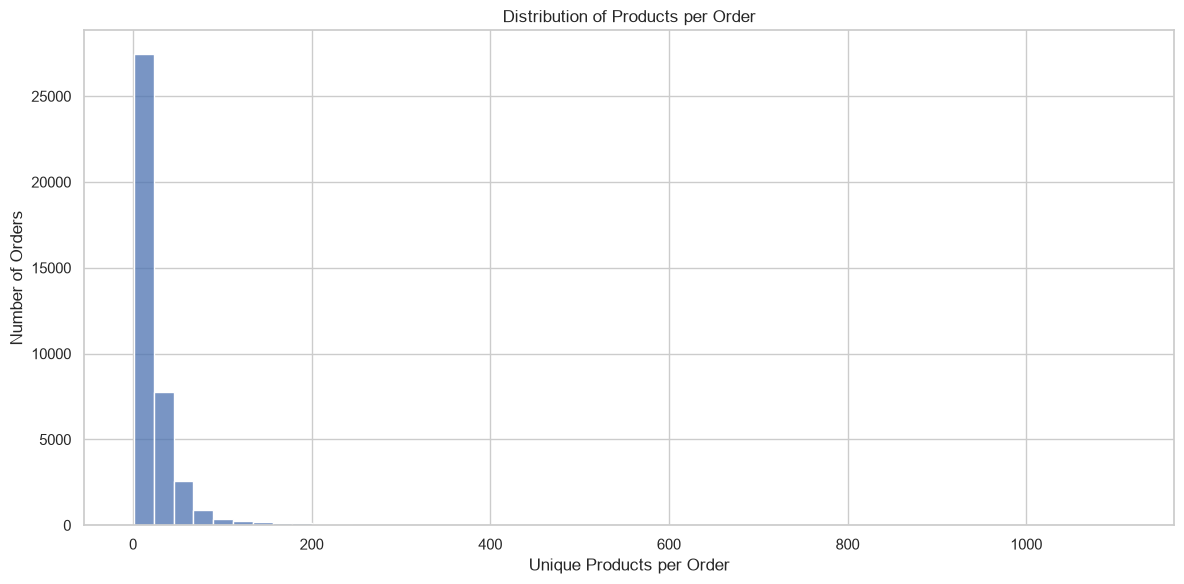

In [9]:
plt.figure(figsize=(12, 6))

sns.histplot(
    items_per_order,
    bins=50
)

plt.title(
    "Distribution of Products per Order"
)

plt.xlabel(
    "Unique Products per Order"
)

plt.ylabel(
    "Number of Orders"
)

plt.tight_layout()
plt.show()

<h2>Remove Single-Item Baskets</h2>

In [10]:
multi_item_invoices = (
    items_per_order[
        items_per_order >= 2
    ]
    .index
)

basket_df = basket_df[
    basket_df["Invoice"].isin(
        multi_item_invoices
    )
].copy()

print(
    f"Orders with at least 2 products: "
    f"{basket_df['Invoice'].nunique():,}"
)

Orders with at least 2 products: 36,392


<h2>Build Transaction-Product Matrix</h2>

In [12]:
basket_matrix = (
    basket_df
    .drop_duplicates(
        [
            "Invoice",
            "StockCode"
        ]
    )
    .assign(
        Purchased=1
    )
    .pivot_table(
        index="Invoice",
        columns="StockCode",
        values="Purchased",
        fill_value=0
    )
)

basket_matrix.head()

StockCode  10002  10002R  10080  10109  10120  10123C  10123G  10124A  10124G  \
Invoice                                                                         
489434    0.0000  0.0000 0.0000 0.0000 0.0000  0.0000  0.0000  0.0000  0.0000   
489435    0.0000  0.0000 0.0000 0.0000 0.0000  0.0000  0.0000  0.0000  0.0000   
489436    0.0000  0.0000 0.0000 0.0000 0.0000  0.0000  0.0000  0.0000  0.0000   
489437    1.0000  0.0000 0.0000 0.0000 0.0000  0.0000  0.0000  0.0000  0.0000   
489438    0.0000  0.0000 0.0000 0.0000 0.0000  0.0000  0.0000  0.0000  0.0000   

StockCode  10125  10133  10134  10135  10138  11001  15030  15034  15036  \
Invoice                                                                    
489434    0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
489435    0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
489436    0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
489437    0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
489438    0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   

StockCode  15039  15044A  15044B  15044C  15044D  15056BL  15056N  15056P  \
Invoice                                                                     
489434    0.0000  0.0000  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000   
489435    0.0000  0.0000  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000   
489436    0.0000  0.0000  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000   
489437    0.0000  0.0000  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000   
489438    0.0000  0.0000  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000   

StockCode  15056bl  15056n  15056p  15058A  15058B  15058C  15059A  15060B  \
Invoice                                                                      
489434      0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
489435      0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
489436      0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
489437      0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
489438      0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   

StockCode  15060b  16008  16010  16011  16012  16014  16015  16016  16020C  \
Invoice                                                                      
489434     0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000  0.0000   
489435     0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000  0.0000   
489436     0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000  0.0000   
489437     0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000  0.0000   
489438     0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000  0.0000   

StockCode  16033  16043  16044  16045  16046  16047  16048  16049  16050  \
Invoice                                                                    
489434    0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
489435    0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
489436    0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
489437    0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
489438    0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   

StockCode  16051  16052  16053  16054  16119  16151A  16156L  16156N  16156S  \
Invoice                                                                        
489434    0.0000 0.0000 0.0000 0.0000 0.0000  0.0000  0.0000  0.0000  0.0000   
489435    0.0000 0.0000 0.0000 0.0000 0.0000  0.0000  0.0000  0.0000  0.0000   
489436    0.0000 0.0000 0.0000 0.0000 0.0000  0.0000  0.0000  0.0000  0.0000   
489437    0.0000 0.0000 0.0000 0.0000 0.0000  0.0000  0.0000  0.0000  0.0000   
489438    0.0000 0.0000 0.0000 0.0000 0.0000  0.0000  0.0000  0.0000  0.0000   

StockCode  16161C  16161E  16161G  16161M  16161P  16161U  16162L  16162M  \
Invoice                                                                     
489434     0.0000

<h2>Check Matrix Size</h2>

In [13]:
print(
    f"Orders: {basket_matrix.shape[0]:,}"
)

print(
    f"Products: {basket_matrix.shape[1]:,}"
)

Orders: 36,392
Products: 4,900


<h2>Convert to Boolean</h2>

In [14]:
basket_matrix = basket_matrix.astype(bool)

print(
    basket_matrix.dtypes.value_counts()
)

bool    4900
Name: count, dtype: int64


<h2>Calculate Product Support</h2>

In [15]:
product_support = (
    basket_matrix
    .mean()
    .sort_values(
        ascending=False
    )
)

product_support.head(20)

StockCode
85123A   0.1460
85099B   0.1088
22423    0.1061
21212    0.0856
20725    0.0839
84879    0.0768
47566    0.0728
21232    0.0667
22383    0.0659
20727    0.0644
21931    0.0639
22197    0.0626
22386    0.0616
22411    0.0602
22382    0.0592
22469    0.0588
84991    0.0584
21080    0.0583
22384    0.0577
22139    0.0573
dtype: float64

<h2>Top Products by Basket Support</h2>

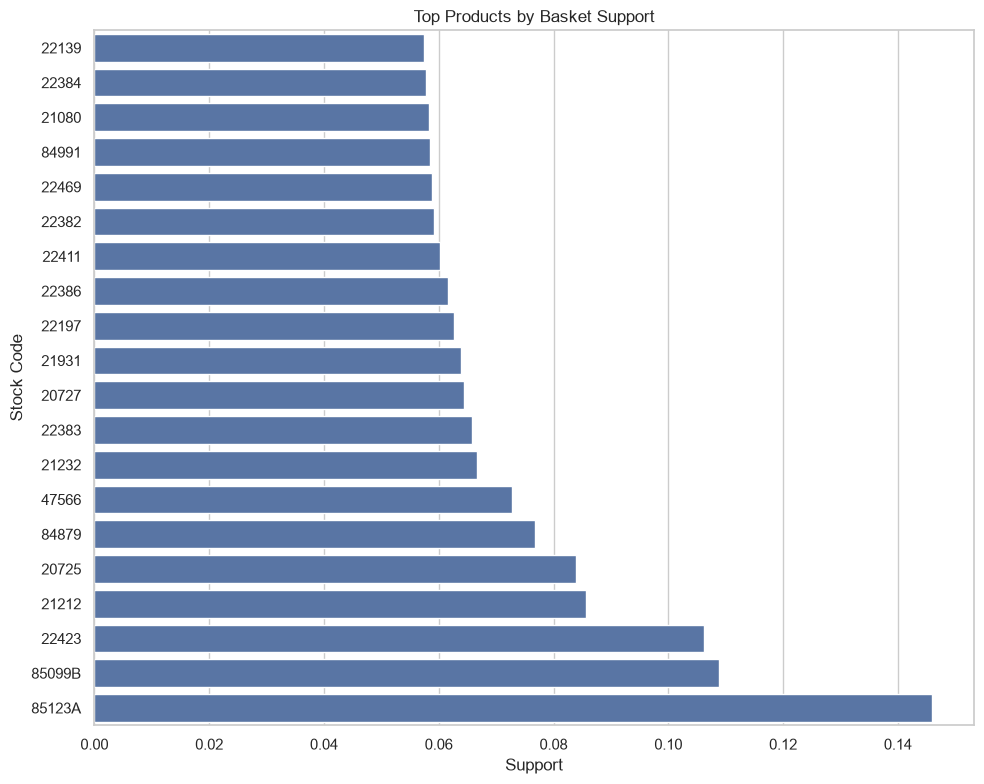

In [16]:
top_support = (
    product_support
    .head(20)
    .sort_values()
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=top_support.values,
    y=top_support.index.astype(str)
)

plt.title(
    "Top Products by Basket Support"
)

plt.xlabel("Support")
plt.ylabel("Stock Code")

plt.tight_layout()
plt.show()

<h2>Add Product Descriptions</h2>

In [17]:
product_lookup = (
    basket_df[
        [
            "StockCode",
            "DescriptionClean"
        ]
    ]
    .drop_duplicates(
        "StockCode"
    )
    .set_index("StockCode")
    ["DescriptionClean"]
    .to_dict()
)

print(
    list(product_lookup.items())[:10]
)

[('85048', '15CM CHRISTMAS GLASS BALL 20 LIGHTS'), ('79323P', 'PINK CHERRY LIGHTS'), ('79323W', 'WHITE CHERRY LIGHTS'), ('22041', 'RECORD FRAME 7" SINGLE SIZE'), ('21232', 'STRAWBERRY CERAMIC TRINKET BOX'), ('22064', 'PINK DOUGHNUT TRINKET POT'), ('21871', 'SAVE THE PLANET MUG'), ('21523', 'FANCY FONT HOME SWEET HOME DOORMAT'), ('22350', 'CAT BOWL'), ('22349', 'DOG BOWL , CHASING BALL DESIGN')]


<h2>Create Readable Support Table</h2>

In [18]:
support_table = (
    product_support
    .reset_index()
)

support_table.columns = [
    "StockCode",
    "Support"
]

support_table["Description"] = (
    support_table["StockCode"]
    .map(product_lookup)
)

support_table = support_table[
    [
        "StockCode",
        "Description",
        "Support"
    ]
]

support_table.head(20)

,StockCode,Description,Support
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0.1460
1,85099B,JUMBO BAG RED WHITE SPOTTY,0.1088
2,22423,REGENCY CAKESTAND 3 TIER,0.1061
3,21212,PACK OF 72 RETRO SPOT CAKE CASES,0.0856
4,20725,LUNCH BAG RED SPOTTY,0.0839
5,84879,ASSORTED COLOUR BIRD ORNAMENT,0.0768
6,47566,PARTY BUNTING,0.0728
7,21232,STRAWBERRY CERAMIC TRINKET BOX,0.0667
8,22383,LUNCHBAG SUKI DESIGN,0.0659
9,20727,LUNCH BAG BLACK SKULL.,0.0644


<h2>Run Apriori</h2>

In [19]:
frequent_itemsets = apriori(
    basket_matrix,
    min_support=0.01,
    use_colnames=True
)

print(
    f"Frequent itemsets found: "
    f"{len(frequent_itemsets):,}"
)

Frequent itemsets found: 1,646


<h2>Inspect Frequent Itemsets</h2>

In [20]:
frequent_itemsets.sort_values(
    "support",
    ascending=False
).head(20)

,support,itemsets
763,0.1460,frozenset({85123A})
760,0.1088,frozenset({85099B})
395,0.1061,frozenset({22423})
87,0.0856,frozenset({21212})
23,0.0839,frozenset({20725})
729,0.0768,frozenset({84879})
659,0.0728,frozenset({47566})
93,0.0667,frozenset({21232})
383,0.0659,frozenset({22383})
25,0.0644,frozenset({20727})


<h2>Add Itemset Size</h2>

In [21]:
frequent_itemsets["itemset_size"] = (
    frequent_itemsets["itemsets"]
    .apply(len)
)

frequent_itemsets[
    "itemset_size"
].value_counts().sort_index()

itemset_size
1    774
2    716
3    146
4     10
Name: count, dtype: int64

<h2>Most Frequent Pairs</h2>

In [22]:
frequent_pairs = frequent_itemsets[
    frequent_itemsets["itemset_size"] == 2
].copy()

frequent_pairs = (
    frequent_pairs
    .sort_values(
        "support",
        ascending=False
    )
)

frequent_pairs.head(20)

,support,itemsets,itemset_size
1315,0.0392,"frozenset({22386, 85099B})",2
1167,0.0364,"frozenset({21931, 85099B})",2
1111,0.0339,"frozenset({21733, 85123A})",2
886,0.0330,"frozenset({20727, 20725})",2
1055,0.0329,"frozenset({84991, 21212})",2
1481,0.0325,"frozenset({85099F, 85099B})",2
906,0.0323,"frozenset({22383, 20725})",2
1321,0.0318,"frozenset({85099B, 22411})",2
907,0.0318,"frozenset({22384, 20725})",2
1030,0.0305,"frozenset({21977, 21212})",2


<h2>Make Pair Names Readable</h2>

In [23]:
def itemset_to_names(itemset):
    return [
        product_lookup.get(
            item,
            str(item)
        )
        for item in itemset
    ]


frequent_pairs["ProductNames"] = (
    frequent_pairs["itemsets"]
    .apply(itemset_to_names)
)

frequent_pairs.head(20)

,support,itemsets,itemset_size,ProductNames
1315,0.0392,"frozenset({22386, 85099B})",2,"[JUMBO BAG PINK WITH WHITE SPOTS, JUMBO BAG RE..."
1167,0.0364,"frozenset({21931, 85099B})",2,"[JUMBO STORAGE BAG SUKI, JUMBO BAG RED WHITE S..."
1111,0.0339,"frozenset({21733, 85123A})",2,"[RED HANGING HEART T-LIGHT HOLDER, WHITE HANGI..."
886,0.0330,"frozenset({20727, 20725})",2,"[LUNCH BAG BLACK SKULL., LUNCH BAG RED SPOTTY]"
1055,0.0329,"frozenset({84991, 21212})",2,"[60 TEATIME FAIRY CAKE CASES, PACK OF 72 RETRO..."
1481,0.0325,"frozenset({85099F, 85099B})",2,"[JUMBO BAG STRAWBERRY, JUMBO BAG RED WHITE SPO..."
906,0.0323,"frozenset({22383, 20725})",2,"[LUNCHBAG SUKI DESIGN, LUNCH BAG RED SPOTTY]"
1321,0.0318,"frozenset({85099B, 22411})",2,"[JUMBO BAG RED WHITE SPOTTY, JUMBO SHOPPER VIN..."
907,0.0318,"frozenset({22384, 20725})",2,"[LUNCHBAG PINK RETROSPOT, LUNCH BAG RED SPOTTY]"
1030,0.0305,"frozenset({21977, 21212})",2,"[PACK OF 60 PINK PAISLEY CAKE CASES, PACK OF 7..."


<h2>Create Readable Pair Table</h2>

In [24]:
pair_rows = []

for _, row in frequent_pairs.iterrows():

    items = list(row["itemsets"])

    if len(items) == 2:

        pair_rows.append({
            "ProductA_Code": items[0],
            "ProductB_Code": items[1],
            "ProductA": product_lookup.get(
                items[0],
                str(items[0])
            ),
            "ProductB": product_lookup.get(
                items[1],
                str(items[1])
            ),
            "Support": row["support"]
        })

pair_table = pd.DataFrame(
    pair_rows
)

pair_table.head(20)

,ProductA_Code,ProductB_Code,ProductA,ProductB,Support
0,22386,85099B,JUMBO BAG PINK WITH WHITE SPOTS,JUMBO BAG RED WHITE SPOTTY,0.0392
1,21931,85099B,JUMBO STORAGE BAG SUKI,JUMBO BAG RED WHITE SPOTTY,0.0364
2,21733,85123A,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,0.0339
3,20727,20725,LUNCH BAG BLACK SKULL.,LUNCH BAG RED SPOTTY,0.0330
4,84991,21212,60 TEATIME FAIRY CAKE CASES,PACK OF 72 RETRO SPOT CAKE CASES,0.0329
5,85099F,85099B,JUMBO BAG STRAWBERRY,JUMBO BAG RED WHITE SPOTTY,0.0325
6,22383,20725,LUNCHBAG SUKI DESIGN,LUNCH BAG RED SPOTTY,0.0323
7,85099B,22411,JUMBO BAG RED WHITE SPOTTY,JUMBO SHOPPER VINTAGE RED PAISLEY,0.0318
8,22384,20725,LUNCHBAG PINK RETROSPOT,LUNCH BAG RED SPOTTY,0.0318
9,21977,21212,PACK OF 60 PINK PAISLEY CAKE CASES,PACK OF 72 RETRO SPOT CAKE CASES,0.0305


<h2>Visualize Top Product Pairs</h2>

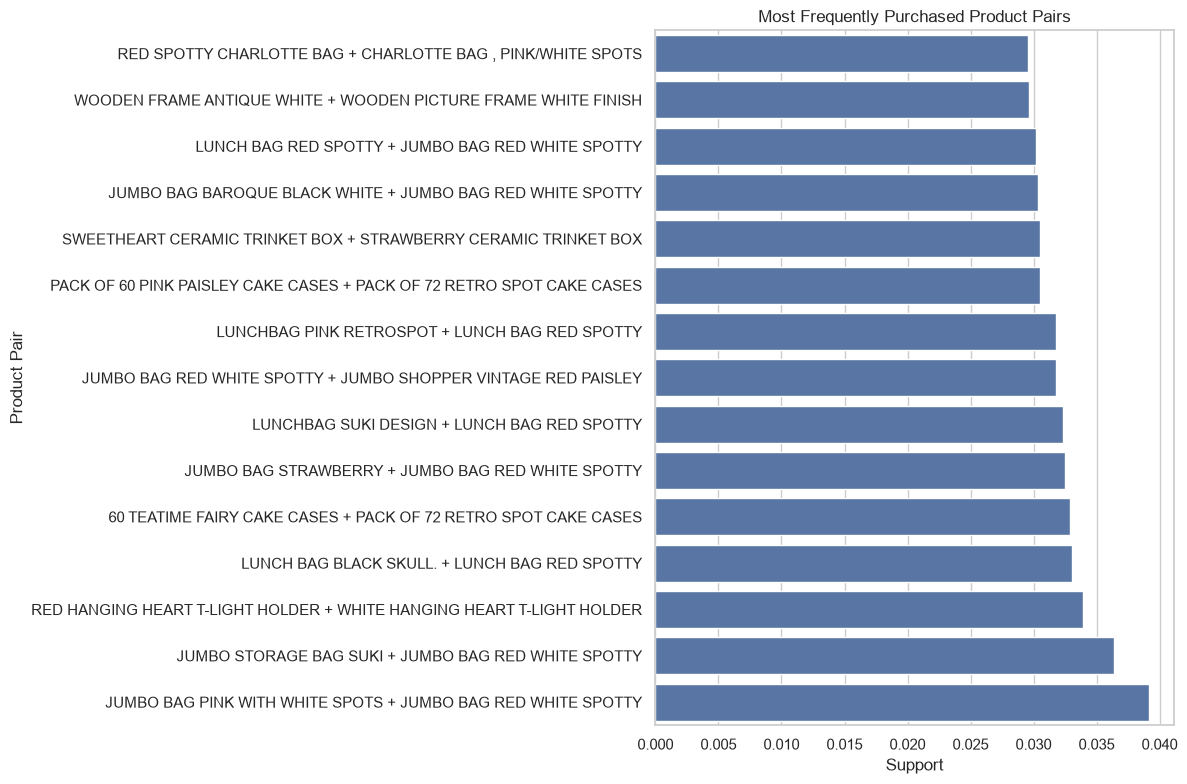

In [25]:
pair_table["Pair"] = (
    pair_table["ProductA"]
    + " + "
    + pair_table["ProductB"]
)

top_pairs = (
    pair_table
    .sort_values(
        "Support",
        ascending=False
    )
    .head(15)
    .sort_values("Support")
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_pairs,
    x="Support",
    y="Pair"
)

plt.title(
    "Most Frequently Purchased Product Pairs"
)

plt.xlabel("Support")
plt.ylabel("Product Pair")

plt.tight_layout()
plt.show()

<h2>Association Rules</h2>

In [26]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.2
)

print(
    f"Association rules generated: "
    f"{len(rules):,}"
)

Association rules generated: 1,866


<h2>Understand the Rule Columns</h2>

In [27]:
rules.columns.tolist()

['antecedents',
 'consequents',
 'antecedent support',
 'consequent support',
 'support',
 'confidence',
 'lift',
 'representativity',
 'leverage',
 'conviction',
 'zhangs_metric',
 'jaccard',
 'certainty',
 'kulczynski']

<h2>Understand Support</h2>
Suppose:

A → B

Support tells us:

What percentage of all baskets contain both A and B?

Formally: Support(A → B) = P(A ∩ B)

<h2>Understand Confidence</h2>
Confidence asks:

If a customer bought A, how often did they also buy B?

Confidence(A → B) = P(B | A)

<h2>Understand Lift</h2>
Lift is particularly useful.

Lift(A → B) = P(B | A) / P(B)

Interpretation:

Lift = 1 → No meaningful association


Lift > 1 → Positive association


Lift < 1 → Negative association

For example: Lift = 3 means B is purchased with A about 3× as often as would be expected based on B's overall popularity.

<h2>Clean the Association Rules</h2>

In [28]:
rules_clean = rules.copy()

rules_clean["Antecedent"] = (
    rules_clean["antecedents"]
    .apply(itemset_to_names)
    .apply(lambda x: " + ".join(x))
)

rules_clean["Consequent"] = (
    rules_clean["consequents"]
    .apply(itemset_to_names)
    .apply(lambda x: " + ".join(x))
)

<h2>Select Important Columns</h2>

In [29]:
rules_table = rules_clean[
    [
        "Antecedent",
        "Consequent",
        "support",
        "confidence",
        "lift"
    ]
].copy()

rules_table.columns = [
    "Antecedent",
    "Consequent",
    "Support",
    "Confidence",
    "Lift"
]

rules_table.head()

,Antecedent,Consequent,Support,Confidence,Lift
0,EDWARDIAN PARASOL NATURAL,EDWARDIAN PARASOL BLACK,0.0122,0.4341,18.5005
1,EDWARDIAN PARASOL BLACK,EDWARDIAN PARASOL NATURAL,0.0122,0.5211,18.5005
2,EDWARDIAN PARASOL BLACK,EDWARDIAN PARASOL RED,0.0109,0.4637,23.6344
3,EDWARDIAN PARASOL RED,EDWARDIAN PARASOL BLACK,0.0109,0.5546,23.6344
4,RED SPOTTY BOWL,BLUE SPOTTY BOWL,0.0117,0.4389,23.0828


<h2>Top Rules by Lift</h2>

In [30]:
strong_rules = rules_table[
    rules_table["Support"] >= 0.005
].copy()

strong_rules = strong_rules[
    strong_rules["Confidence"] >= 0.20
].copy()

top_lift_rules = (
    strong_rules
    .sort_values(
        "Lift",
        ascending=False
    )
)

top_lift_rules.head(20)

,Antecedent,Consequent,Support,Confidence,Lift
1714,POPPY'S PLAYHOUSE LIVINGROOM,POPPY'S PLAYHOUSE KITCHEN + POPPY'S PLAYHOUSE ...,0.0112,0.7252,47.3800
1713,POPPY'S PLAYHOUSE KITCHEN + POPPY'S PLAYHOUSE ...,POPPY'S PLAYHOUSE LIVINGROOM,0.0112,0.7343,47.3800
1711,POPPY'S PLAYHOUSE LIVINGROOM + POPPY'S PLAYHOU...,POPPY'S PLAYHOUSE BEDROOM,0.0112,0.8629,44.6679
1716,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE LIVINGROOM + POPPY'S PLAYHOU...,0.0112,0.5818,44.6679
1715,POPPY'S PLAYHOUSE KITCHEN,POPPY'S PLAYHOUSE LIVINGROOM + POPPY'S PLAYHOU...,0.0112,0.5512,43.5135
1712,POPPY'S PLAYHOUSE LIVINGROOM + POPPY'S PLAYHOU...,POPPY'S PLAYHOUSE KITCHEN,0.0112,0.8872,43.5135
684,COFFEE MUG CAT + BIRD DESIGN,COFFEE MUG DOG + BALL DESIGN,0.0109,0.6143,42.6639
685,COFFEE MUG DOG + BALL DESIGN,COFFEE MUG CAT + BIRD DESIGN,0.0109,0.7538,42.6639
899,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE LIVINGROOM,0.0127,0.6558,42.3129
898,POPPY'S PLAYHOUSE LIVINGROOM,POPPY'S PLAYHOUSE BEDROOM,0.0127,0.8174,42.3129


<h2>Top Rules by Confidence</h2>

In [31]:
top_confidence_rules = (
    strong_rules
    .sort_values(
        "Confidence",
        ascending=False
    )
)

top_confidence_rules.head(20)

,Antecedent,Consequent,Support,Confidence,Lift
1855,PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY...,GREEN REGENCY TEACUP AND SAUCER,0.0118,0.9190,24.7362
1700,PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY...,GREEN REGENCY TEACUP AND SAUCER,0.0202,0.9052,24.3647
1759,WOODLAND CHARLOTTE BAG + STRAWBERRY CHARLOTTE ...,RED SPOTTY CHARLOTTE BAG,0.0116,0.9038,16.1635
1681,PINK REGENCY TEACUP AND SAUCER + REGENCY CAKES...,GREEN REGENCY TEACUP AND SAUCER,0.0136,0.8935,24.0505
1801,"CHARLOTTE BAG , SUKI DESIGN + STRAWBERRY CHARL...",RED SPOTTY CHARLOTTE BAG,0.0122,0.8882,15.8841
1712,POPPY'S PLAYHOUSE LIVINGROOM + POPPY'S PLAYHOU...,POPPY'S PLAYHOUSE KITCHEN,0.0112,0.8872,43.5135
1437,SET/6 RED SPOTTY PAPER CUPS + SET/20 RED SPOTT...,SET/6 RED SPOTTY PAPER PLATES,0.0133,0.8707,32.2031
1853,PINK REGENCY TEACUP AND SAUCER + GREEN REGENCY...,ROSES REGENCY TEACUP AND SAUCER,0.0118,0.8707,22.3146
1711,POPPY'S PLAYHOUSE LIVINGROOM + POPPY'S PLAYHOU...,POPPY'S PLAYHOUSE BEDROOM,0.0112,0.8629,44.6679
1699,PINK REGENCY TEACUP AND SAUCER + GREEN REGENCY...,ROSES REGENCY TEACUP AND SAUCER,0.0202,0.8507,21.8017


<h2>Top Rules by Support</h2>

In [32]:
top_support_rules = (
    strong_rules
    .sort_values(
        "Support",
        ascending=False
    )
)

top_support_rules.head(20)

,Antecedent,Consequent,Support,Confidence,Lift
771,JUMBO BAG PINK WITH WHITE SPOTS,JUMBO BAG RED WHITE SPOTTY,0.0392,0.6363,5.8507
772,JUMBO BAG RED WHITE SPOTTY,JUMBO BAG PINK WITH WHITE SPOTS,0.0392,0.3603,5.8507
568,JUMBO STORAGE BAG SUKI,JUMBO BAG RED WHITE SPOTTY,0.0364,0.5692,5.2337
569,JUMBO BAG RED WHITE SPOTTY,JUMBO STORAGE BAG SUKI,0.0364,0.3345,5.2337
478,WHITE HANGING HEART T-LIGHT HOLDER,RED HANGING HEART T-LIGHT HOLDER,0.0339,0.2323,4.8171
477,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,0.0339,0.7031,4.8171
178,LUNCH BAG BLACK SKULL.,LUNCH BAG RED SPOTTY,0.0330,0.5126,6.1060
179,LUNCH BAG RED SPOTTY,LUNCH BAG BLACK SKULL.,0.0330,0.3935,6.1060
391,PACK OF 72 RETRO SPOT CAKE CASES,60 TEATIME FAIRY CAKE CASES,0.0329,0.3841,6.5757
390,60 TEATIME FAIRY CAKE CASES,PACK OF 72 RETRO SPOT CAKE CASES,0.0329,0.5630,6.5757


<h2>Compare Support, Confidence and Lift</h2>

In [33]:
top_rules_comparison = (
    strong_rules
    .sort_values(
        "Lift",
        ascending=False
    )
    .head(20)
)
top_rules_comparison

,Antecedent,Consequent,Support,Confidence,Lift
1714,POPPY'S PLAYHOUSE LIVINGROOM,POPPY'S PLAYHOUSE KITCHEN + POPPY'S PLAYHOUSE ...,0.0112,0.7252,47.3800
1713,POPPY'S PLAYHOUSE KITCHEN + POPPY'S PLAYHOUSE ...,POPPY'S PLAYHOUSE LIVINGROOM,0.0112,0.7343,47.3800
1711,POPPY'S PLAYHOUSE LIVINGROOM + POPPY'S PLAYHOU...,POPPY'S PLAYHOUSE BEDROOM,0.0112,0.8629,44.6679
1716,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE LIVINGROOM + POPPY'S PLAYHOU...,0.0112,0.5818,44.6679
1715,POPPY'S PLAYHOUSE KITCHEN,POPPY'S PLAYHOUSE LIVINGROOM + POPPY'S PLAYHOU...,0.0112,0.5512,43.5135
1712,POPPY'S PLAYHOUSE LIVINGROOM + POPPY'S PLAYHOU...,POPPY'S PLAYHOUSE KITCHEN,0.0112,0.8872,43.5135
684,COFFEE MUG CAT + BIRD DESIGN,COFFEE MUG DOG + BALL DESIGN,0.0109,0.6143,42.6639
685,COFFEE MUG DOG + BALL DESIGN,COFFEE MUG CAT + BIRD DESIGN,0.0109,0.7538,42.6639
899,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE LIVINGROOM,0.0127,0.6558,42.3129
898,POPPY'S PLAYHOUSE LIVINGROOM,POPPY'S PLAYHOUSE BEDROOM,0.0127,0.8174,42.3129


<h2>Lift Distribution</h2>

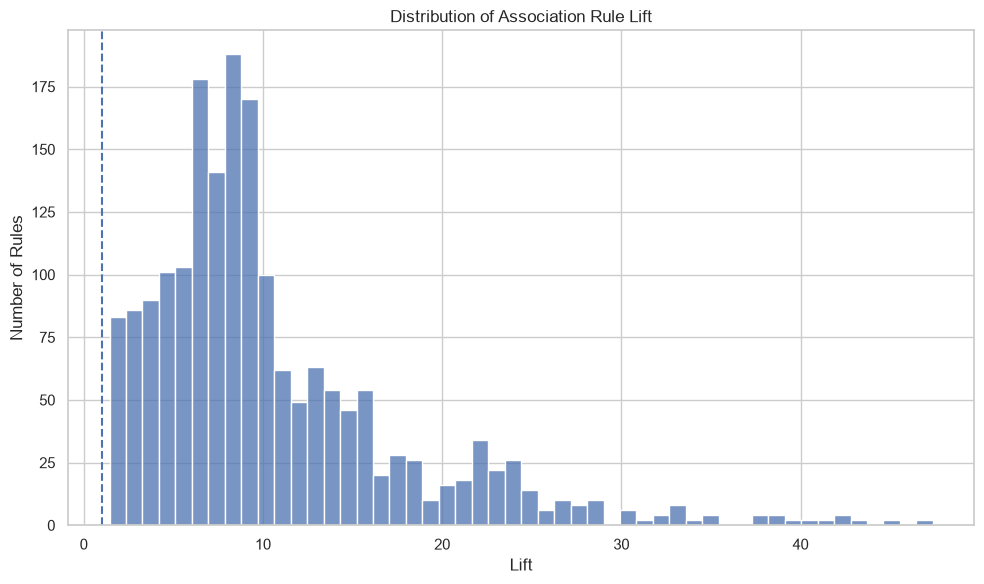

In [34]:
plt.figure(figsize=(10, 6))

sns.histplot(
    strong_rules["Lift"],
    bins=50
)

plt.axvline(
    1,
    linestyle="--"
)

plt.title(
    "Distribution of Association Rule Lift"
)

plt.xlabel("Lift")
plt.ylabel("Number of Rules")

plt.tight_layout()
plt.show()

<h2>Confidence vs Lift</h2>

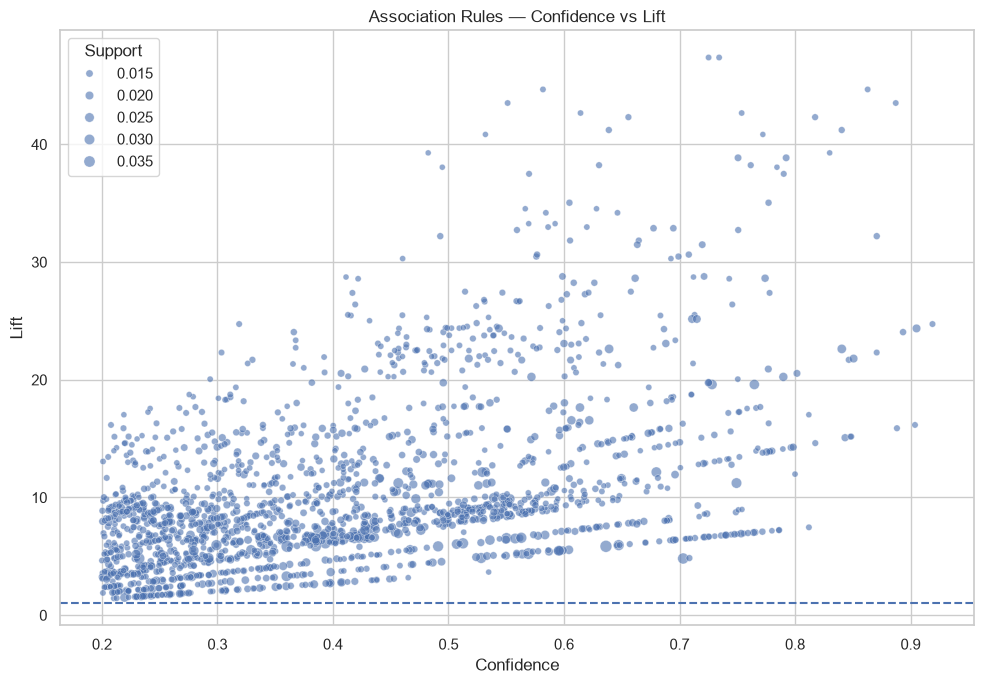

In [35]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=strong_rules,
    x="Confidence",
    y="Lift",
    size="Support",
    alpha=0.6
)

plt.axhline(
    1,
    linestyle="--"
)

plt.title(
    "Association Rules — Confidence vs Lift"
)

plt.xlabel("Confidence")
plt.ylabel("Lift")

plt.tight_layout()
plt.show()

<h2>Top 15 Rules by Lift — Visualization</h2>

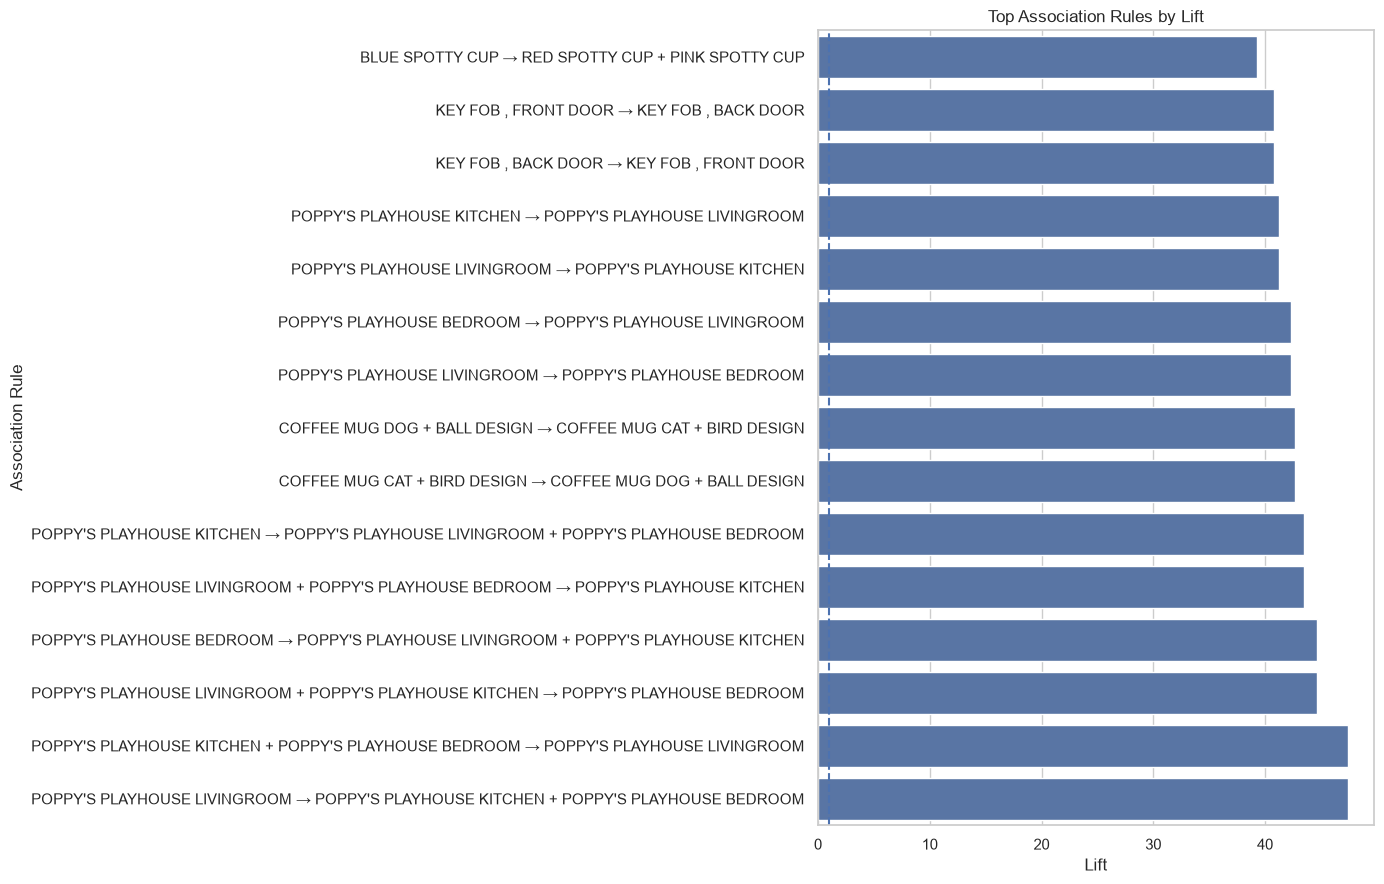

In [36]:
top_rules_plot = (
    strong_rules
    .sort_values(
        "Lift",
        ascending=False
    )
    .head(15)
    .copy()
)

top_rules_plot["Rule"] = (
    top_rules_plot["Antecedent"]
    + " → "
    + top_rules_plot["Consequent"]
)

top_rules_plot = (
    top_rules_plot
    .sort_values("Lift")
)

plt.figure(figsize=(14, 9))

sns.barplot(
    data=top_rules_plot,
    x="Lift",
    y="Rule"
)

plt.axvline(
    1,
    linestyle="--"
)

plt.title(
    "Top Association Rules by Lift"
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")

plt.tight_layout()
plt.show()

<h2>Find Strong Product Recommendations</h2>

In [37]:
recommendation_rules = strong_rules[
    (strong_rules["Confidence"] >= 0.40) &
    (strong_rules["Lift"] >= 1.5)
].copy()

recommendation_rules = (
    recommendation_rules
    .sort_values(
        [
            "Confidence",
            "Lift"
        ],
        ascending=False
    )
)

recommendation_rules.head(30)

,Antecedent,Consequent,Support,Confidence,Lift
1855,PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY...,GREEN REGENCY TEACUP AND SAUCER,0.0118,0.9190,24.7362
1700,PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY...,GREEN REGENCY TEACUP AND SAUCER,0.0202,0.9052,24.3647
1759,WOODLAND CHARLOTTE BAG + STRAWBERRY CHARLOTTE ...,RED SPOTTY CHARLOTTE BAG,0.0116,0.9038,16.1635
1681,PINK REGENCY TEACUP AND SAUCER + REGENCY CAKES...,GREEN REGENCY TEACUP AND SAUCER,0.0136,0.8935,24.0505
1801,"CHARLOTTE BAG , SUKI DESIGN + STRAWBERRY CHARL...",RED SPOTTY CHARLOTTE BAG,0.0122,0.8882,15.8841
1712,POPPY'S PLAYHOUSE LIVINGROOM + POPPY'S PLAYHOU...,POPPY'S PLAYHOUSE KITCHEN,0.0112,0.8872,43.5135
1437,SET/6 RED SPOTTY PAPER CUPS + SET/20 RED SPOTT...,SET/6 RED SPOTTY PAPER PLATES,0.0133,0.8707,32.2031
1853,PINK REGENCY TEACUP AND SAUCER + GREEN REGENCY...,ROSES REGENCY TEACUP AND SAUCER,0.0118,0.8707,22.3146
1711,POPPY'S PLAYHOUSE LIVINGROOM + POPPY'S PLAYHOU...,POPPY'S PLAYHOUSE BEDROOM,0.0112,0.8629,44.6679
1699,PINK REGENCY TEACUP AND SAUCER + GREEN REGENCY...,ROSES REGENCY TEACUP AND SAUCER,0.0202,0.8507,21.8017


<h2>Create Recommendation Lookup</h2>

In [38]:
recommendation_lookup = {}

for _, row in recommendation_rules.iterrows():

    antecedent = row["Antecedent"]
    consequent = row["Consequent"]

    recommendation_lookup.setdefault(
        antecedent,
        []
    ).append({
        "recommendation": consequent,
        "confidence": row["Confidence"],
        "lift": row["Lift"],
        "support": row["Support"]
    })

In [39]:
list(
    recommendation_lookup.items()
)[:5]

[('PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER + REGENCY CAKESTAND 3 TIER',
  [{'recommendation': 'GREEN REGENCY TEACUP AND SAUCER',
    'confidence': 0.9189765458422173,
    'lift': 24.73623850317306,
    'support': 0.011843262255440756}]),
 ('PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER',
  [{'recommendation': 'GREEN REGENCY TEACUP AND SAUCER',
    'confidence': 0.9051724137931034,
    'lift': 24.36467047541318,
    'support': 0.020196746537700594},
   {'recommendation': 'REGENCY CAKESTAND 3 TIER',
    'confidence': 0.5775862068965517,
    'lift': 5.44124184348416,
    'support': 0.012887447790723237},
   {'recommendation': 'GREEN REGENCY TEACUP AND SAUCER + REGENCY CAKESTAND 3 TIER',
    'confidence': 0.5307881773399015,
    'lift': 26.79118356415214,
    'support': 0.011843262255440756}]),
 ('WOODLAND CHARLOTTE BAG + STRAWBERRY CHARLOTTE BAG + CHARLOTTE BAG , PINK/WHITE SPOTS',
  [{'recommendation': 'RED SPOTTY CHARLOTTE BAG',
    'confidenc

<h2>Product-Level Recommendation Function</h2>

In [40]:
def recommend_products(
    product_name,
    rules_df,
    top_n=5
):
    recommendations = (
        rules_df[
            rules_df["Antecedent"]
            .str.contains(
                product_name,
                case=False,
                na=False
            )
        ]
        .sort_values(
            [
                "Lift",
                "Confidence"
            ],
            ascending=False
        )
        .head(top_n)
    )

    return recommendations[
        [
            "Antecedent",
            "Consequent",
            "Support",
            "Confidence",
            "Lift"
        ]
    ]

<h2>Test Recommendation Function</h2>

In [41]:
support_table.head(20)[
    "Description"
].tolist()

['WHITE HANGING HEART T-LIGHT HOLDER',
 'JUMBO BAG RED WHITE SPOTTY',
 'REGENCY CAKESTAND 3 TIER',
 'PACK OF 72 RETRO SPOT CAKE CASES',
 'LUNCH BAG RED SPOTTY',
 'ASSORTED COLOUR BIRD ORNAMENT',
 'PARTY BUNTING',
 'STRAWBERRY CERAMIC TRINKET BOX',
 'LUNCHBAG SUKI DESIGN',
 'LUNCH BAG BLACK SKULL.',
 'JUMBO STORAGE BAG SUKI',
 'POPCORN HOLDER , SMALL',
 'JUMBO BAG PINK WITH WHITE SPOTS',
 'JUMBO SHOPPER VINTAGE RED PAISLEY',
 'LUNCHBAG SPACEBOY DESIGN',
 'HEART OF WICKER SMALL',
 '60 TEATIME FAIRY CAKE CASES',
 'SET/20 RED SPOTTY PAPER NAPKINS',
 'LUNCHBAG PINK RETROSPOT',
 'RETRO SPOT TEA SET CERAMIC 11 PC']

In [42]:
recommend_products(
    "HEART",
    strong_rules,
    top_n=10
)

,Antecedent,Consequent,Support,Confidence,Lift
838,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.0152,0.6635,31.4794
840,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN TREE CHRISTMAS SCANDINAVIAN,0.0105,0.4603,30.2940
862,CERAMIC HEART FAIRY CAKE MONEY BANK,CERAMIC STRAWBERRY CAKE MONEY BANK,0.0108,0.5317,22.0892
665,SMALL HEART MEASURING SPOONS,HEART MEASURING SPOONS LARGE,0.0124,0.4608,20.6754
664,HEART MEASURING SPOONS LARGE,SMALL HEART MEASURING SPOONS,0.0124,0.5573,20.6754
1004,HANGING HEART ZINC T-LIGHT HOLDER,SINGLE HEART ZINC T-LIGHT HOLDER,0.0176,0.4515,15.2555
1003,SINGLE HEART ZINC T-LIGHT HOLDER,HANGING HEART ZINC T-LIGHT HOLDER,0.0176,0.5961,15.2555
991,SET OF 3 HEART COOKIE CUTTERS,SET OF 3 BUTTERFLY COOKIE CUTTERS,0.0145,0.4238,13.8556
1485,STRAWBERRY CERAMIC TRINKET BOX + WHITE HANGING...,SWEETHEART CERAMIC TRINKET BOX,0.0108,0.5262,12.9382
1486,SWEETHEART CERAMIC TRINKET BOX,STRAWBERRY CERAMIC TRINKET BOX + WHITE HANGING...,0.0108,0.2649,12.9382


<h2>Find Three-Product Combinations</h2>

In [43]:
frequent_triplets = frequent_itemsets[
    frequent_itemsets["itemset_size"] == 3
].copy()

frequent_triplets = (
    frequent_triplets
    .sort_values(
        "support",
        ascending=False
    )
)

print(
    f"Frequent triplets: "
    f"{len(frequent_triplets):,}"
)

frequent_triplets.head(20)

Frequent triplets: 146


,support,itemsets,itemset_size
1628,0.0202,"frozenset({22698, 22697, 22699})",3
1604,0.0186,"frozenset({22386, 21931, 85099B})",3
1522,0.0178,"frozenset({22355, 20724, 22356})",3
1535,0.0173,"frozenset({20727, 22384, 20725})",3
1618,0.0171,"frozenset({22386, 85099B, 22411})",3
1607,0.0171,"frozenset({21931, 85099B, 22411})",3
1511,0.0170,"frozenset({20724, 20723, 22356})",3
1576,0.0169,"frozenset({21977, 84991, 21212})",3
1546,0.0168,"frozenset({22383, 22384, 20725})",3
1504,0.0168,"frozenset({20719, 20724, 22356})",3


<h2>Make Triplets Readable</h2>

In [44]:
frequent_triplets["ProductNames"] = (
    frequent_triplets["itemsets"]
    .apply(itemset_to_names)
)

frequent_triplets[
    [
        "ProductNames",
        "support"
    ]
].head(20)

,ProductNames,support
1628,"[PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.0202
1604,"[JUMBO BAG PINK WITH WHITE SPOTS, JUMBO STORAG...",0.0186
1522,"[CHARLOTTE BAG , SUKI DESIGN, RED SPOTTY CHARL...",0.0178
1535,"[LUNCH BAG BLACK SKULL., LUNCHBAG PINK RETROSP...",0.0173
1618,"[JUMBO BAG PINK WITH WHITE SPOTS, JUMBO BAG RE...",0.0171
1607,"[JUMBO STORAGE BAG SUKI, JUMBO BAG RED WHITE S...",0.0171
1511,"[RED SPOTTY CHARLOTTE BAG, STRAWBERRY CHARLOTT...",0.0170
1576,"[PACK OF 60 PINK PAISLEY CAKE CASES, 60 TEATIM...",0.0169
1546,"[LUNCHBAG SUKI DESIGN, LUNCHBAG PINK RETROSPOT...",0.0168
1504,"[WOODLAND CHARLOTTE BAG, RED SPOTTY CHARLOTTE ...",0.0168


<h2>Basket Size Analysis</h2>

In [45]:
basket_size_summary = pd.Series({
    "Average Products per Order":
        items_per_order.mean(),

    "Median Products per Order":
        items_per_order.median(),

    "Maximum Products per Order":
        items_per_order.max(),

    "Minimum Products per Order":
        items_per_order.min()
})

basket_size_summary

Average Products per Order      24.8634
Median Products per Order       15.0000
Maximum Products per Order   1,110.0000
Minimum Products per Order       1.0000
dtype: float64

<h2>Orders with Multiple Products</h2>

In [46]:
multi_product_percentage = (
    (items_per_order >= 2).mean()
    * 100
)

print(
    f"Orders containing 2+ products: "
    f"{multi_product_percentage:.2f}%"
)

Orders containing 2+ products: 90.80%


<h2>Orders with 5+ Products</h2>

In [47]:
large_basket_percentage = (
    (items_per_order >= 5).mean()
    * 100
)

print(
    f"Orders containing 5+ products: "
    f"{large_basket_percentage:.2f}%"
)

Orders containing 5+ products: 79.94%


<h2>Basket Size Distribution</h2>

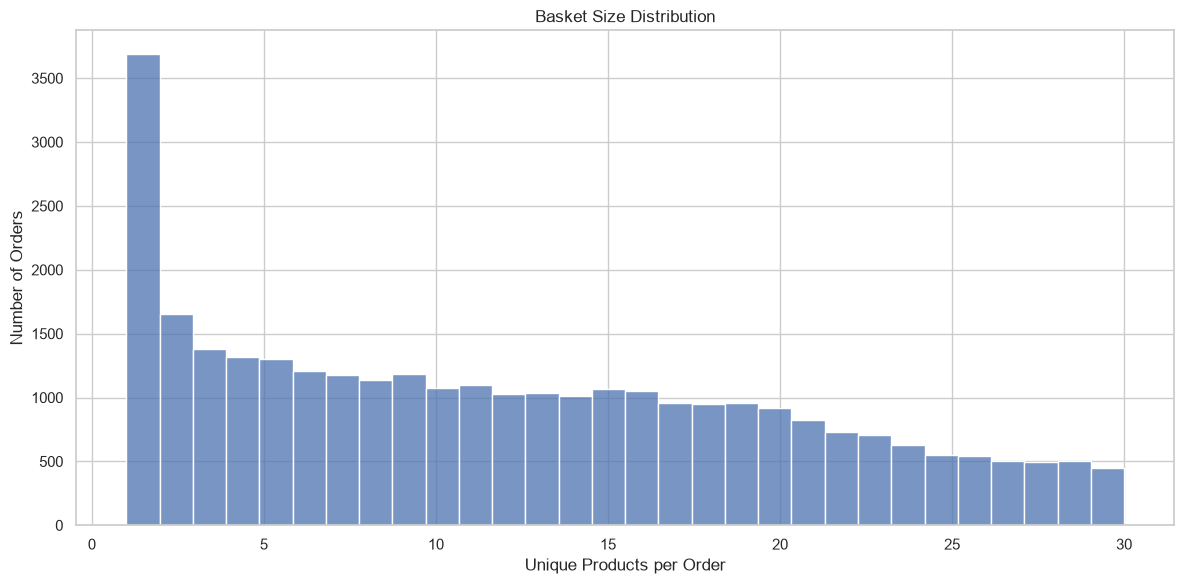

In [48]:
plt.figure(figsize=(12, 6))

sns.histplot(
    items_per_order[
        items_per_order <= 30
    ],
    bins=30
)

plt.title(
    "Basket Size Distribution"
)

plt.xlabel(
    "Unique Products per Order"
)

plt.ylabel(
    "Number of Orders"
)

plt.tight_layout()
plt.show()

<h2>Save Frequent Itemsets</h2>

In [49]:
frequent_itemsets_export = (
    frequent_itemsets.copy()
)

frequent_itemsets_export[
    "itemsets"
] = (
    frequent_itemsets_export[
        "itemsets"
    ]
    .apply(
        lambda x: " | ".join(
            str(i) for i in x
        )
    )
)

frequent_itemsets_export.to_csv(
    REPORTS_DIR /
    "frequent_itemsets.csv",
    index=False
)

<h2>Save Association Rules</h2>

In [50]:
rules_table.to_csv(
    REPORTS_DIR /
    "association_rules.csv",
    index=False
)

<h2>Save Strong Rules</h2>

In [51]:
strong_rules.to_csv(
    REPORTS_DIR /
    "strong_association_rules.csv",
    index=False
)

<h2>Save Product Support</h2>

In [52]:
support_table.to_csv(
    REPORTS_DIR /
    "product_basket_support.csv",
    index=False
)

<h2>Save Recommendations</h2>

In [53]:
recommendation_rules.to_csv(
    REPORTS_DIR /
    "product_recommendation_rules.csv",
    index=False
)

<h2>Save Figures</h2>

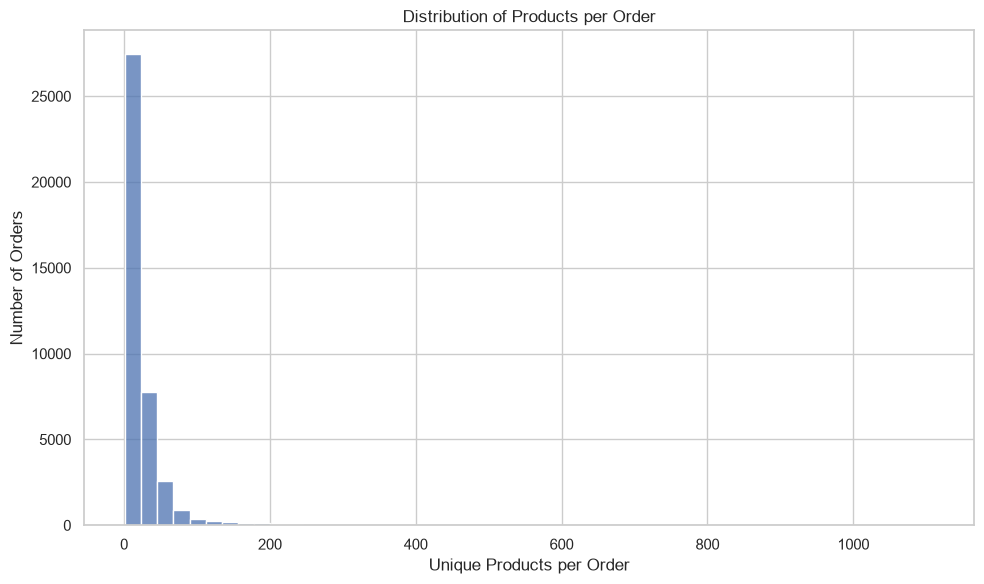

In [54]:
plt.figure(figsize=(10, 6))

sns.histplot(
    items_per_order,
    bins=50
)

plt.title(
    "Distribution of Products per Order"
)

plt.xlabel(
    "Unique Products per Order"
)

plt.ylabel(
    "Number of Orders"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "basket_size_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h2>Final Basket Analysis Summary</h2>

In [55]:
print("=" * 70)
print("BASKET ANALYSIS COMPLETE")
print("=" * 70)

print(
    f"\nValid multi-product orders:"
    f"\n{basket_matrix.shape[0]:,}"
)

print(
    f"\nProducts analyzed:"
    f"\n{basket_matrix.shape[1]:,}"
)

print(
    f"\nFrequent itemsets:"
    f"\n{len(frequent_itemsets):,}"
)

print(
    f"\nAssociation rules:"
    f"\n{len(rules_table):,}"
)

print(
    f"\nStrong association rules:"
    f"\n{len(strong_rules):,}"
)

print(
    f"\nRecommendation rules:"
    f"\n{len(recommendation_rules):,}"
)

print(
    f"\nAverage products per order:"
    f"\n{items_per_order.mean():.2f}"
)

print(
    f"\nMedian products per order:"
    f"\n{items_per_order.median():.0f}"
)

print("=" * 70)

BASKET ANALYSIS COMPLETE

Valid multi-product orders:
36,392

Products analyzed:
4,900

Frequent itemsets:
1,646

Association rules:
1,866

Strong association rules:
1,866

Recommendation rules:
891

Average products per order:
24.86

Median products per order:
15
